In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from phentax.waveform import IMRPhenomTHM

FIGSIZE = (10, 6)
import scienceplots
plt.style.use(["science", "notebook"])

## Gradient computation with `jax.grad`

This notebook shows how to compute gradients of a phentax waveform and how to validate them against finite differences.

We use only the (2,2) mode and a short observation window to keep compilation fast.

### Setup: waveform generator and reference parameters

In [3]:
T_obs = 5 * 86400.0  # 5 days in seconds

imr = IMRPhenomTHM(
    higher_modes=None,
    include_negative_modes=False,
    t_low_fit=True,
    coarse_grain=False,
    T=T_obs,
)

# Reference parameters
m1_ref   = jnp.array(1e7)   # solar masses
m2_ref   = jnp.array(5e6)
chi1_ref = jnp.array(0.3)
chi2_ref = jnp.array(0.1)
dist_ref = 500.0             # Mpc
iota_ref = jnp.pi / 3.0
phi_ref  = 0.0
psi_ref  = 1.0
f_min    = 1e-4              # Hz
delta_t  = 60.0             # s

### Reference waveform

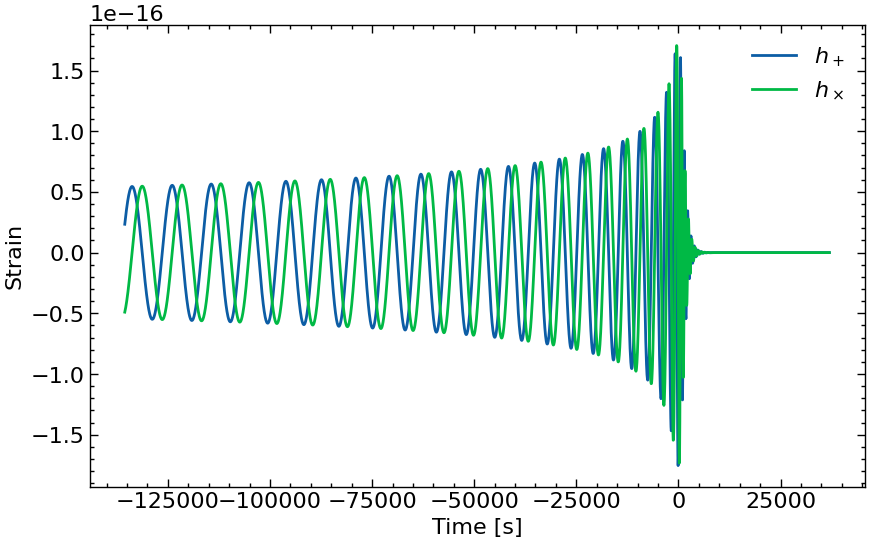

In [4]:
times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
    m1_ref, m2_ref, chi1_ref, chi2_ref,
    dist_ref, phi_ref, f_min, f_min,
    iota_ref, psi_ref,
    delta_t=delta_t,
)

fig = plt.figure(figsize=FIGSIZE)
plt.plot(times[0][mask[0]], h_plus[0][mask[0]], label=r"$h_+$")
plt.plot(times[0][mask[0]], h_cross[0][mask[0]], label=r"$h_\times$")
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()

### Scalar objective function

We define a simple scalar function to differentiate: the squared $\ell_2$ norm of $h_+$ (analogous to a matched-filter SNR$^2$).

In [5]:
def snr2(m1):
    """Squared L2 norm of h+ as a function of m1."""
    times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
        m1, m2_ref, chi1_ref, chi2_ref,
        dist_ref, phi_ref, f_min, f_min,
        iota_ref, psi_ref,
        delta_t=delta_t,
    )
    return jnp.sum(h_plus ** 2)

### Gradient via `jax.grad`

In [6]:
grad_snr2 = jax.grad(snr2)

g_analytic = grad_snr2(m1_ref)
print(f"jax.grad  d(SNR²)/dm1 = {g_analytic}")

jax.grad  d(SNR²)/dm1 = 4.307124442997659e-37


### Gradient validation via finite differences

Central finite differences provide a reference gradient independent of JAX's autodiff graph:

$$
\frac{\partial f}{\partial m_1} \approx \frac{f(m_1 + \varepsilon) - f(m_1 - \varepsilon)}{2\,\varepsilon}
$$

The optimal $\varepsilon$ balances truncation error $O(\varepsilon^2)$ and floating-point cancellation.

In [7]:
def finite_diff(f, x, eps):
    return (f(x + eps) - f(x - eps)) / (2.0 * eps)

In [8]:
eps_values = jnp.logspace(1, 6, 30)  # eps in solar masses

fd_grads = [float(finite_diff(snr2, m1_ref, eps)) for eps in eps_values]

print(f"Finite diff (eps=1e4 M_sun):  d(SNR²)/dm1 = {fd_grads[15]:.6e}")

Finite diff (eps=1e4 M_sun):  d(SNR²)/dm1 = 3.001422e-37


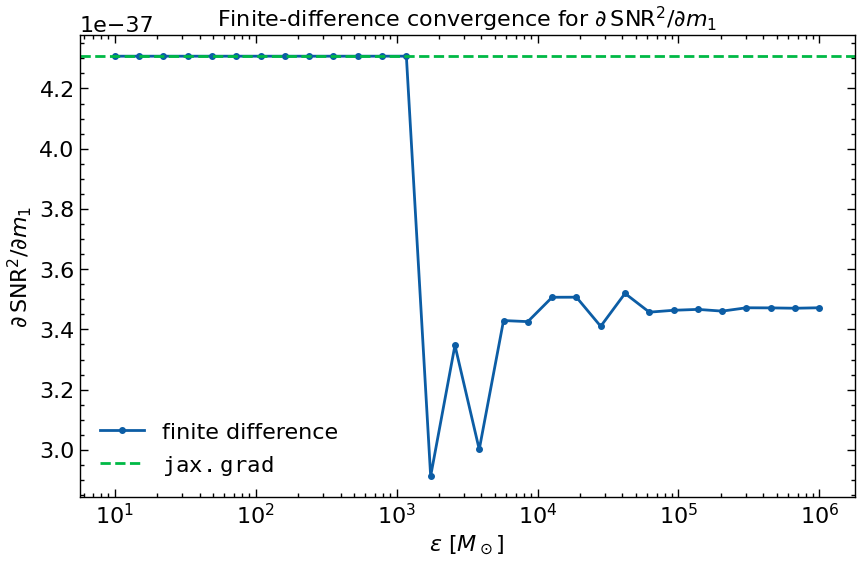

In [9]:
fig = plt.figure(figsize=FIGSIZE)
plt.semilogx(eps_values, fd_grads, marker="o", ms=4, label="finite difference")
plt.axhline(float(g_analytic), ls="--", color="C1", label=r"$\mathtt{jax.grad}$")
plt.xlabel(r"$\varepsilon$ [$M_\odot$]")
plt.ylabel(r"$\partial\,\mathrm{SNR}^2 / \partial m_1$")
plt.legend()
plt.title(r"Finite-difference convergence for $\partial\,\mathrm{SNR}^2/\partial m_1$")
plt.show()

The plateau in the middle of the $\varepsilon$ range is the reliable estimate of the gradient.
- For small $\varepsilon$: floating-point cancellation dominates.
- For large $\varepsilon$: truncation error ($O(\varepsilon^2)$) dominates.

### Gradient w.r.t. multiple parameters

With finite differences we can approximate the full gradient vector $\nabla_{\theta} \text{SNR}^2$.

In [10]:
def snr2_m1_m2(m1, m2):
    times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
        m1, m2, chi1_ref, chi2_ref,
        dist_ref, phi_ref, f_min, f_min,
        iota_ref, psi_ref,
        delta_t=delta_t,
    )
    return jnp.sum(h_plus ** 2)

eps_m1 = 1e4   # solar masses
eps_m2 = 5e3

fd_dm1 = finite_diff(lambda m1: snr2_m1_m2(m1, m2_ref), m1_ref, eps_m1)
fd_dm2 = finite_diff(lambda m2: snr2_m1_m2(m1_ref, m2), m2_ref, eps_m2)

print(f"d(SNR²)/dm1 ≈ {float(fd_dm1):.6e}  (eps={eps_m1:.0e} M_sun)")
print(f"d(SNR²)/dm2 ≈ {float(fd_dm2):.6e}  (eps={eps_m2:.0e} M_sun)")

d(SNR²)/dm1 ≈ 3.545252e-37  (eps=1e+04 M_sun)
d(SNR²)/dm2 ≈ 1.142164e-36  (eps=5e+03 M_sun)
